In [1]:
# Import Libraries
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [2]:
# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = 1
V0 = var(r'V_0')
alp = var(r'α')
M = var('M')
N = var('N')
beta = var('β') # coupling variable
alp = 4

In [3]:
# Expression for V and dv/dphi
def V(M,phi):
    return (M^(4+alp))/phi^alp

def dVdphi(M,phi):
    return -alp*V(M,phi)/phi

In [4]:
show(V(M,phi)) # Test of V

M^8/φ^4

In [13]:
# Cosmological constants
h = 0.7
ohm_m = 0.31
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho**2/(k**2)) # current critical energy density
A = 0.65
M_val = ((rho_c0*(8*pi)^(alp/2))^(1/(alp+4)))*A
gam = 1
beta = 0
Ni = 0
show(M_val)

(1.10977135095917e-15)*pi^(1/4)

In [14]:
# Klein Gordon Equation Written as two first order differential equations in X
def CoupledSteinhardt(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    
    Vfunc = V(M_val,X[0])
    dVfunc = dVdphi(M_val,X[0])

    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2- beta*rho_m/H2
    return [x1prime,x2prime]

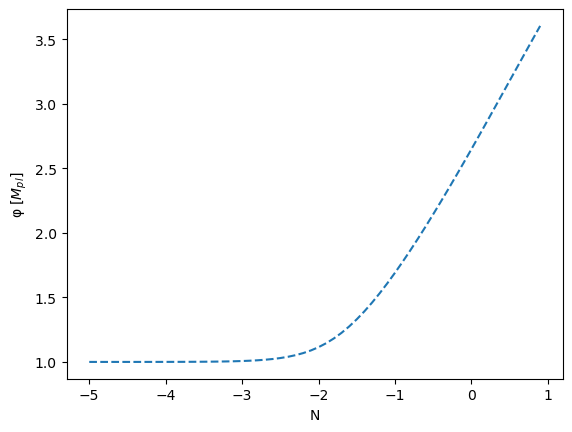

In [15]:
# Test when φ = 1 and φ' = 0
Nrange = np.arange(-5,1,.1) # N values
Ni = 0

sol = odeint(CoupledSteinhardt,[1,0],t=Nrange)
phi_sol = sol[:,0]
phi_prime = sol[:,1]

z_values = exp(-Nrange) # N = -ln(z+1)
plt.xlabel("N")
plt.ylabel(r"φ $[M_{pl}]$")
plt.plot(Nrange,phi_sol,'--')

In [16]:
# Function to determine other cosmological parameters using numerical values of φ and φ'
def other_parameters(fi,dfi,N):
    '''
    Function that determines other cosmological parameters using
    fi = φ
    dfi = φ'
    N => N = ln(a)
    '''
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Pot = V(M_val,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + Pot # Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ # Equation of State wΦ
    weff = Pφ/(rho_φ +rho_m)
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m,weff

In [17]:
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(phi_sol,phi_prime,Nrange)
#show(rho_s)
Z = z+1

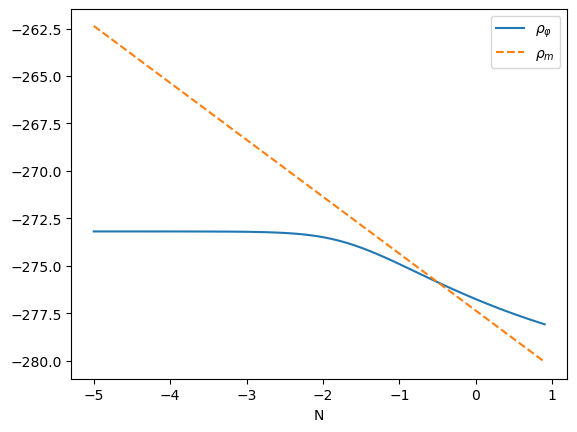

In [18]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,log(rho_s),label=r"$ρ_φ$")
plt.plot(Nrange,log(rho_m),label=r"$ρ_m$",ls='--')
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
#plt.xlim([-1,1])
plt.legend()
#plt.savefig(r"log of $ρ_φ$ and $ρ_m$ for Q = {}.png".format(np.round(Q,3))) 

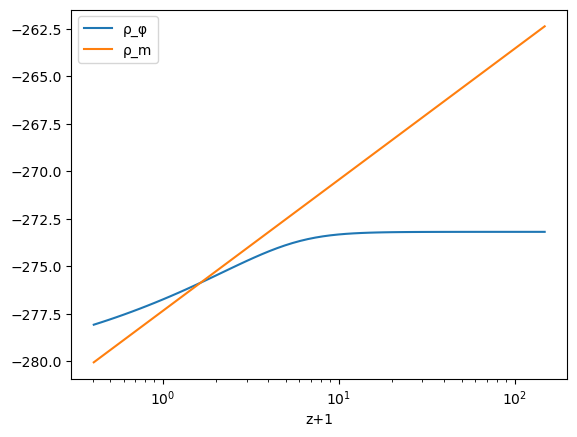

In [19]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1

#plt.plot(Z,phi_sol, label  =r"φ")
#plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,log(rho_s),label=r"ρ_φ")
plt.plot(Z,log(rho_m),label=r"ρ_m")
#show(Y_Q)
#plt.plot(Z,(Y_Q),label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
#show(max(O_Q))
#show(max(Y_Q))
#plt.plot(Z,log(O_Q),label=r"Ω_φ") 
#plt.plot(Z,log(O_m),label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
#plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

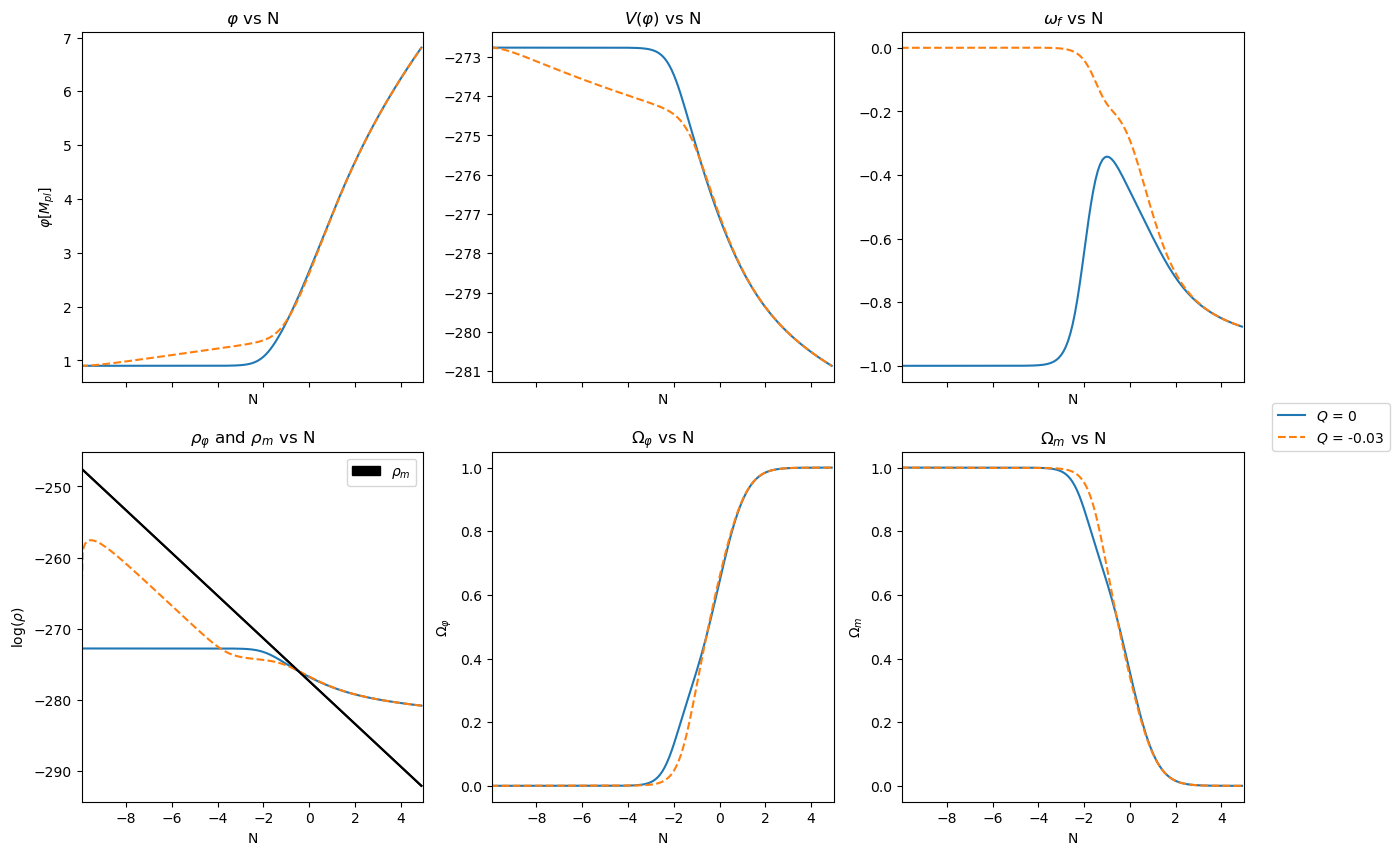

In [20]:
Nrange = np.arange(-10,5,.1)
Q_list = []
Ni = Nrange[0]
w_list = []
from itertools import cycle
StyleList = ['solid','dashed','dashdot','dotted']
cmap = ['red','blue','green']
lines = cycle(StyleList)
colours = cycle(cmap)

fig, axs = plt.subplots(2,3, figsize=(15, 10),sharex=True)
def xaxis(x,label,i,ls):
    
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[0,0].set(ylabel = r"$φ[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$ vs {}".format(label))
    
    #axs[0,1].plot(x,solQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,1].set(ylabel = r"$φ$'$[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$' vs {}".format(label))

    axs[0,1].plot(x,log(potentials),label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    axs[0,1].set(xlabel = "{}".format(label),title=r"$V(φ)$ vs {}".format(label))
    
    axs[1,0].plot(x,log(rho),label=r"rho", linestyle = "{}".format(ls))
    axs[1,0].plot(x,log(rho_m),label=r"rho_m",linestyle = "solid", color = "black")
    axs[1,0].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label),title=r"$ρ_φ$ and $ρ_m$ vs {}".format(label))
    axs[1,0].set_xlim(-9.95,4.99)
    
    axs[1,1].plot(x,O_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,1].set(ylabel = r"$Ω_φ$", xlabel = "{}".format(label),title=r"$Ω_φ$ vs {}".format(label))
    #axs[1,1].set_xlim(-9,5)
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,2].set(ylabel = r"$Ω_m$", xlabel = "{}".format(label),title=r"$Ω_m$ vs {}".format(label))
    #axs[1,2].legend()

    if i == 0:
        axs[0,2].plot(x,w,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    else:
        axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))
        
    #axs[0,2].legend()
    #axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))

    if label == "z+1":
        axs[0,0].set_xscale('log')
        axs[0,0].xaxis.set_inverted(True)
        secax0 = axs[0,0].twiny()
        secax0.set_xlim(Nrange[0],Nrange[-1])
        secax0.set_xlabel('N')
    
#Q_values = -np.arange(0,1,.1) # These are different initial values of coupling constant Q
Q_values = [0,-0.03,-0.1,-1,1,0.03,0.1]
Q_values = [0,-0.03]
#Q_values = [-1,-0.1,-0.03,0,0.03,0.1,1]
#Q_values = [0]
for i in Q_values:
    Ni = Nrange[0]
    Ni=0
    #Q_list.append("$φ_i$ = {}".format(np.round(i,4)))
    #solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
    beta = i
    Q_list.append("$Q$ = {}".format(np.round(i,4)))
    solQ = odeint(CoupledSteinhardt,[.9,0],t=Nrange) # change 0.5 back to i
    potentials = (V(M_val,solQ[:,0]))
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    w_list.append((i,round(max(w),3)))
    Z = z+1
    xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1
#axs[1,0].legend()
import matplotlib.patches as mpatches
black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # allows us to add separate legend for rho_m
axs[1,0].legend(handles=[black_patch])

fig.legend(Q_list,loc='center right')
#fig.suptitle("Plots of cosmological parameters")
#fig.savefig(r"Plots of φ,V(φ),ω,ρφ,ρm,Ωφ,Ωm for Coupled Steinhardt with ${}$ .png".format(Q_list))

In [23]:
show(w_list)

[(0, -0.342),
 (-0.0300000000000000, 1.0),
 (-0.100000000000000, 1.0),
 (-1, 1.0),
 (1, 1.0),
 (0.0300000000000000, 1.0),
 (0.100000000000000, 1.0)]